## set up virtual environment and library

- numpy,
- scikit learn,
- matplotlib,
- pandas

In [ ]:
%pip install numpy scikit-learn matplotlib pandas

## Project_1

### Task 1: Data Exploration and Insights (15%)
Task Description
Analyze the AG News dataset to understand its structure and characteristics.
Suggested analyses:

- Class distribution
- Average and median text length (overall and per class)
- Most frequent words per class
- Word clouds per class
- Distribution of n-gram frequencies
-  …

Please don’t limit yourself to these examples and try to summarize the data with numbers and
graphs. Please highlight some of the most important findings in your report.

---
Deliverable:

- Summarize key findings and observations in your report
- Highlight patterns that may influence modeling choices

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# how data looks like, here is an example
df = pd.read_csv("train.csv")
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


the datasets have 3 attributes, they are Class, Index, Title, Description.
- Class Index ∈ {1,2,3,4}
- Title ∈ String
- Description ∈ String

#### Analyze class distribution

In [ ]:
"""
train.csv and test.csv has n piece of data
each piece of data belongs to a certain class, which is represented as 1, 2, 3, 4

1 calculate each class has how many piece of data, N_i, i ∈ 1,2,3,4 is noted as result
2 N_i / Total : percentage of each class
3 plot the result as bar diagram

"""


In [ ]:
df = pd.read_csv("train.csv")



shape:  (120000, 3)

columns:  Index(['Class Index', 'Title', 'Description'], dtype='object')

dtypes:
 Class Index     int64
Title          object
Description    object
dtype: object


In [77]:
class_lst = df["Class Index"].to_list()

abs_accumulated_class = dict()
for i in class_lst:
    k = abs_accumulated_class.keys()
    if i in k:
        abs_accumulated_class[i] += 1
    else:
        abs_accumulated_class[i] = 1
relevant_accumulated_class = abs_accumulated_class

size_class = len(class_lst)
for key, values in relevant_accumulated_class.items():
    relevant_accumulated_class[key] = relevant_accumulated_class[key] / size_class
keys = relevant_accumulated_class.keys()


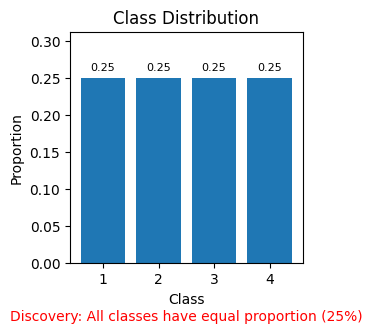

In [76]:
# plot the result
plt.figure(figsize=(3, 3))
bars = plt.bar(
    relevant_accumulated_class.keys(),
    relevant_accumulated_class.values()
)

max_val = max(relevant_accumulated_class.values())
plt.ylim(0, max_val * 1.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, # put text at middle
        height + max_val * 0.03,     # vertical offset
        f"{height:.2f}",  # content of the text, keep 2 decimal
        ha="center",   # horizonal alignment
        va="bottom",   # vertical alignment
        fontsize=8,
        color="black"
    )
plt.text(
    0.5, -0.25,
    "Discovery: All classes have equal proportion (25%)",
    ha="center",
    transform=plt.gca().transAxes,
    color = "red"
)
plt.xlabel("Class")
plt.ylabel("Proportion")
plt.title("Class Distribution")

plt.show()

#### Analyze Average and median text length (overall and per class)

#### Analyze Most frequent words per class

#### Analyze Word clouds per class

#### Analyze Distribution of n-gram frequencies

#### Analyze ...

### Task 2: Pre-processing (15%)

#### Task Description
Design and implement a preprocessing pipeline suitable for text modeling.

Possible components include:

- Tokenization  
- Lowercasing  
- Stopword removal  
- Stemming or lemmatization  
- Handling punctuation or numbers  
- Subword tokenization (for Transformer models)

---

#### Report Requirements

In your report, you should:

- Clearly describe your final preprocessing pipeline  
- Justify which steps you included and which you excluded

### Task 3: Classical Language Modeling (20%)

#### Task 3.1 – N-gram Language Models
For this task you should implement a bigram and a trigram language model
Requirements:

- Compute smoothed probabilities (e.g., Laplace smoothing)
- Generate short text sequences from each model
- Compute and compare perplexity across n-gram sizes

#### Task 3.2 – Comparison with a Neural Language Model
Build a simple neural language model consisting of:

- An embedding layer
- One LSTM or GRU layer
- A softmax output layer

Then compare against n-gram models on:

- Perplexity
- Quality of generated text
- And, Training time

### Task 4: Transformer Fine-tuning (30%)

Fine-tune a lightweight transformer model on the dataset.
Suggested model:

- DistilBERT

Requirements:

- Split the data into train/validation/test split
- Implement at least two tokenization approaches (e.g., WordPiece vs. Byte-Pair Encoding)
- Evaluation metrics:

- Accuracy
- Macro-F1
- Confusion matrix

In [ ]:
# https://www.acm.org/publications/proceedings-template

### Task 5: Model Evaluation & Benchmarking (20%)
Evaluate your models using multiple perspectives. First, randomly subsample 100 test instances and
evaluate your model on them, and test different evaluation approaches:

- Metric-based evaluation (accuracy, F1, perplexity) - like a standard evaluation as above, using
the gold labels
- Human evaluation (you & teammates give ratings) - this would represent a scenario in which
you would not have any gold label, and you need to create the ground truth by yourself
- LLM-as-a-judge evaluation (use any local small LLM or API-free model like Llama 3.1 8B local)
    - this would represent a scenario in which, again, no gold labels would be available, but
instead of annotating them manually, you use an LLM to judge the results.

Analyze differences between gold labels across the three different evaluations.

### Task 6 Report Requirements (3–4 pages)
Your report must include:

- Clear explanation of pipeline design
- Key findings in each task
- All evaluation results and metrics
- Hyperparameters for all models
- Challenges and limitations